# Precprocess the data

## Point source masking

The CIB map is to have sources exceeding $2\;\text{mJy}$ masked with single pixel masks.

## Cluster masking

The tSZ map is to have clusters with mass $M_{500}\ge3\times10^{14}$ are to be masked with radii ranging from $3\theta_{500}$ to $5\theta_{500}$ with a minimum radius of 10 arcminutes.

## Masking with sigma clipping

Until we get access to cluster and point source masks, we use sigma clipping. The process is to compute $\mu$ and $\sigma$, remove all pixels above $\mu+10\times\sigma$ and iterate until no more pixels are removed by this process. Input maps have an NSIDE of 8192, corresponding to 805306368 pixels that are 0.43 arcminutes.

In [2]:
import numpy as np
import astropy.units as u
import healpy as hp
import os
import matplotlib.pyplot as plt

NSIDE: 8192, NPIX: 805306368, Pixel Size: 0.43 arcmin


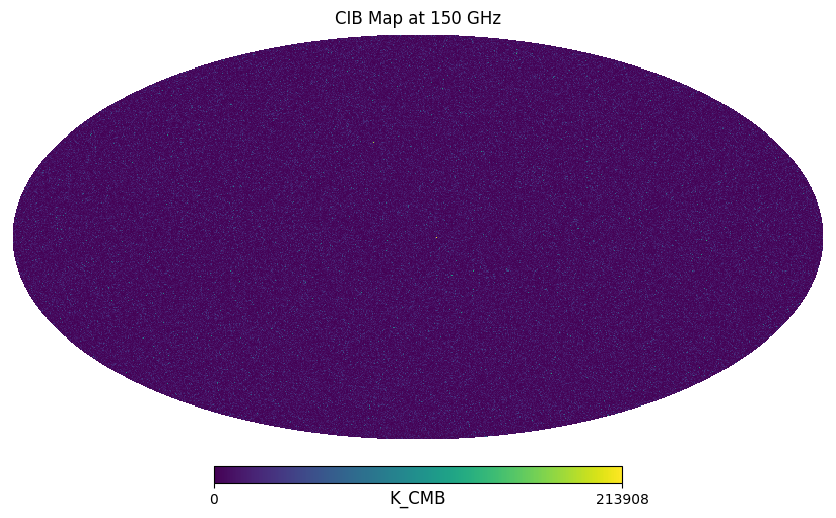

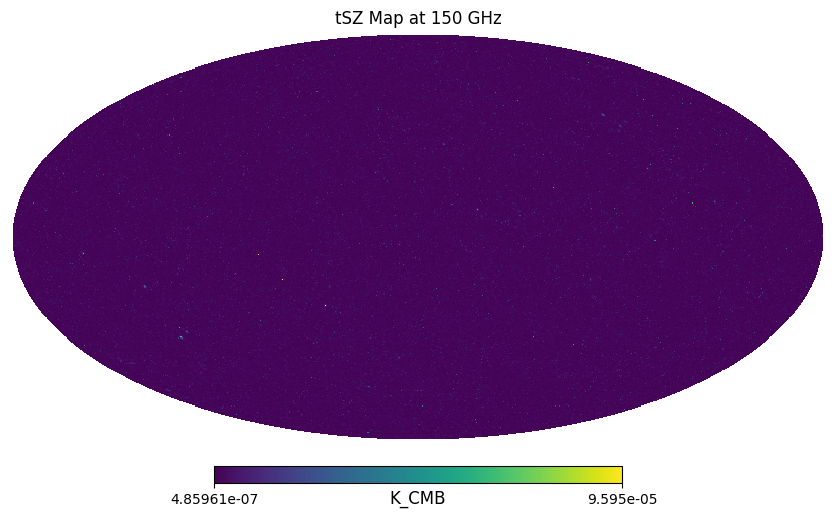

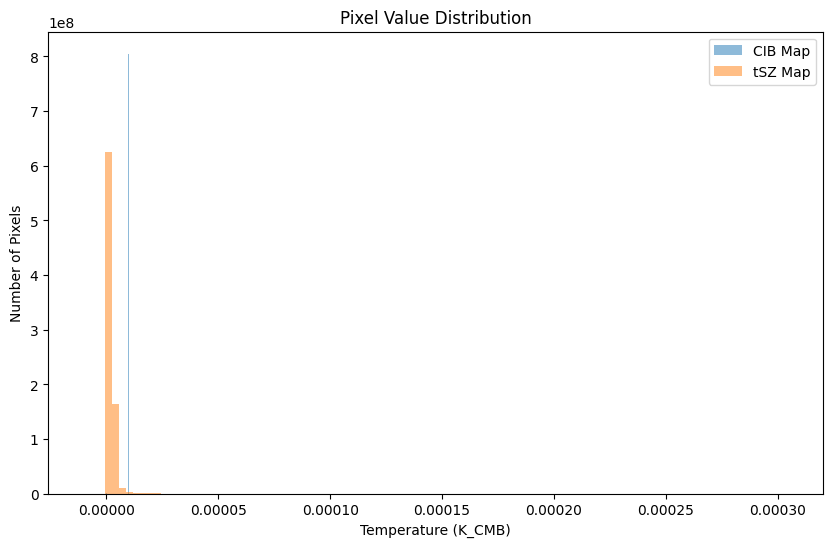

In [ ]:
data_dir = 'data'
plots_dir = 'plots'
os.makedirs(plots_dir, exist_ok=True)

cib_map = hp.read_map(os.path.join(data_dir, 'agora_len_mag_cibmap_act_150ghz.fits'), memmap=True)

hp.mollview(cib_map, title='CIB Map at 150 GHz', unit='K_CMB')
plt.savefig(os.path.join(plots_dir, 'cib_map_150ghz.png'), dpi=300)

tsz_map = hp.read_map(os.path.join(data_dir, 'agora_ltszNG_bahamas80_bnd_unb_1.0e+12_1.0e+18_lensed.fits'), memmap=True)

hp.mollview(tsz_map, title='tSZ Map at 150 GHz', unit='K_CMB')
plt.savefig(os.path.join(plots_dir, 'tsz_map_150ghz.png'), dpi=300)

# Get pixel info:
nside = hp.get_nside(cib_map)
npix = hp.nside2npix(nside)
pix_size = hp.nside2resol(nside, arcmin=True)
print(f"NSIDE: {nside}, NPIX: {npix}, Pixel Size: {pix_size:.2f} arcmin")

# Plot histogram of pixel values:
harsh_clip = 1e-5
cib_map_clipped = np.clip(cib_map, -harsh_clip, harsh_clip)
plt.figure(figsize=(10, 6))
plt.hist(cib_map_clipped.flatten(), bins=100, alpha=0.5, label='CIB Map')
plt.hist(tsz_map.flatten(), bins=100, alpha=0.5, label='tSZ Map')
plt.xlabel('Temperature (K_CMB)')
plt.ylabel('Number of Pixels')
plt.yscale('log')
plt.title('Pixel Value Distribution')
plt.legend()
plt.savefig(os.path.join(plots_dir, 'pixel_value_histogram.png'), dpi=300)

## Low pass filter

Both maps have a low pass filter applied, with $\ell\ge7000$ set to zero.